# SimpleRNN for Next-Day Temperature Forecasting
**Dataset:** [Weather History (Szeged, Hungary), Kaggle](https://www.kaggle.com/datasets/muthuj7/weather-dataset)  
**Framework:** TensorFlow / Keras

**Task:** use the past 14 days of weather (temperature, humidity, wind speed) to predict the next day's temperature, then forecast 7 days ahead.

> **Note:** the Kaggle file contains **hourly** readings (2006–2016), not daily ones. Section A resamples it to **daily means**, which is what the assignment asks for.

In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Part A: Data Understanding and Preprocessing
### A1. Load and explore

In [2]:
# !pip install -q kagglehub     # uncomment if needed
import kagglehub
DATA_ROOT = kagglehub.dataset_download("muthuj7/weather-dataset")
CSV_PATH = glob.glob(os.path.join(DATA_ROOT, "**", "*.csv"), recursive=True)[0]
print("Loaded:", CSV_PATH)

raw = pd.read_csv(CSV_PATH)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
print("\nFirst 10 rows:")
display(raw.head(10))

100%|██████████| 2.23M/2.23M [00:01<00:00, 2.20MB/s]

Extracting files...


Loaded: /root/.cache/kagglehub/datasets/muthuj7/weather-dataset/versions/1/weatherHistory.csv
Shape: (96453, 12)
Columns: ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']

First 10 rows:


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [3]:
# Keep the columns we need and parse the date (use the local timestamp, dropping the "+0200" offset)
COLS = {"Temperature (C)": "temp", "Humidity": "humidity",
        "Wind Speed (km/h)": "wind", "Pressure (millibars)": "pressure"}

hourly = raw[["Formatted Date"] + list(COLS)].rename(columns=COLS)
hourly["date"] = pd.to_datetime(hourly["Formatted Date"].str[:19])
hourly = hourly.drop(columns="Formatted Date").set_index("date").sort_index()

print("Hourly range:", hourly.index.min(), "->", hourly.index.max())
print("\nMissing values (NaN):\n", hourly.isna().sum())
print("\nSuspicious zeros (physically implausible):")
print("  pressure == 0 :", int((hourly["pressure"] == 0).sum()))
print("  humidity == 0 :", int((hourly["humidity"] == 0).sum()))
print("\nSummary statistics:")
display(hourly.describe().T)

Hourly range: 2006-01-01 00:00:00 -> 2016-12-31 23:00:00

Missing values (NaN):
 temp        0
humidity    0
wind        0
pressure    0
dtype: int64

Suspicious zeros (physically implausible):
  pressure == 0 : 1288
  humidity == 0 : 22

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
temp,96453.0,11.932678,9.551546,-21.822222,4.688889,12.0000,18.838889,39.905556
humidity,96453.0,0.734899,0.195473,0.000000,0.600000,0.7800,0.890000,1.000000
wind,96453.0,10.810640,6.913571,0.000000,5.828200,9.9659,14.135800,63.852600
pressure,96453.0,1003.235956,116.969906,0.000000,1011.900000,1016.4500,1021.090000,1046.380000


### A2. Cleaning and daily aggregation
- Pressure (and a few humidity) readings of exactly 0 are sensor errors, so they are treated as **missing**.
- Hourly data is averaged to **daily means**. Days with fewer than 12 hourly readings (partial days) are marked missing.
- Remaining gaps are filled by **time-based interpolation** (the series is smooth, so this is safer than dropping rows, which would break the day-to-day sequence).

In [4]:
hourly.loc[hourly["pressure"] == 0, "pressure"] = np.nan
hourly.loc[hourly["humidity"] == 0, "humidity"] = np.nan

daily = hourly.resample("D").mean()
counts = hourly["temp"].resample("D").count()
daily.loc[counts < 12] = np.nan                       # incomplete days

print("Daily rows:", len(daily), "| missing before imputation:")
print(daily.isna().sum().to_string())

daily = daily.interpolate(method="time", limit_direction="both")
print("\nMissing after imputation:", int(daily.isna().sum().sum()))
print("Date range:", daily.index.min().date(), "->", daily.index.max().date())
display(daily.head(10))

Daily rows: 4018 | missing before imputation:
temp        0
humidity    0
wind        0
pressure    0

Missing after imputation: 0
Date range: 2006-01-01 -> 2016-12-31


,temp,humidity,wind,pressure
date,,,,
2006-01-01,3.873148,0.818333,21.372750,1012.279167
2006-01-02,5.418519,0.844583,17.551683,1010.131667
2006-01-03,2.319444,0.898333,8.417617,1020.805000
2006-01-04,2.274074,0.905417,11.579925,1024.514783
2006-01-05,2.698148,0.948333,9.515100,1021.078182
2006-01-06,2.511806,0.947083,5.665858,1023.403333
2006-01-07,0.992824,0.935833,6.699613,1029.912083
2006-01-08,-1.028009,0.868750,5.289521,1035.372500
2006-01-09,-1.848611,0.797083,5.247929,1034.671250


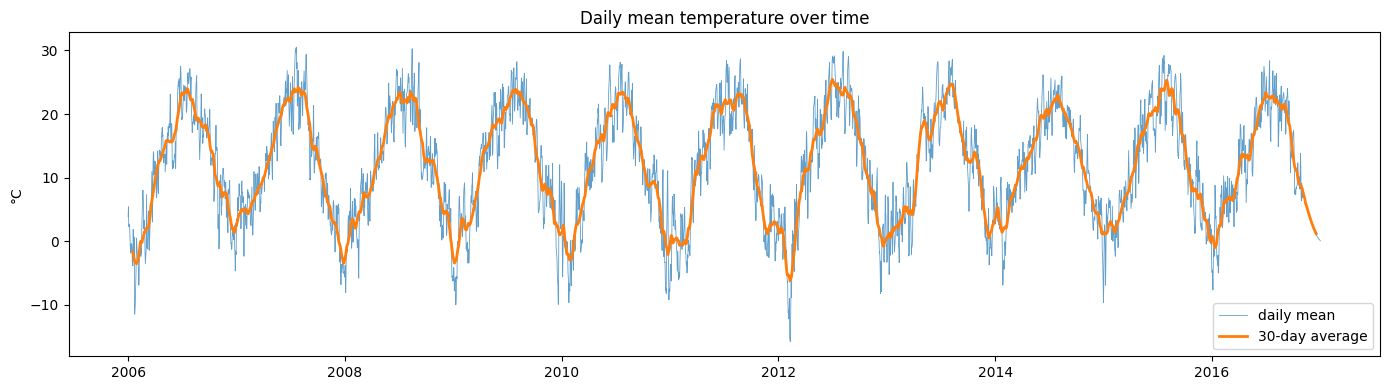

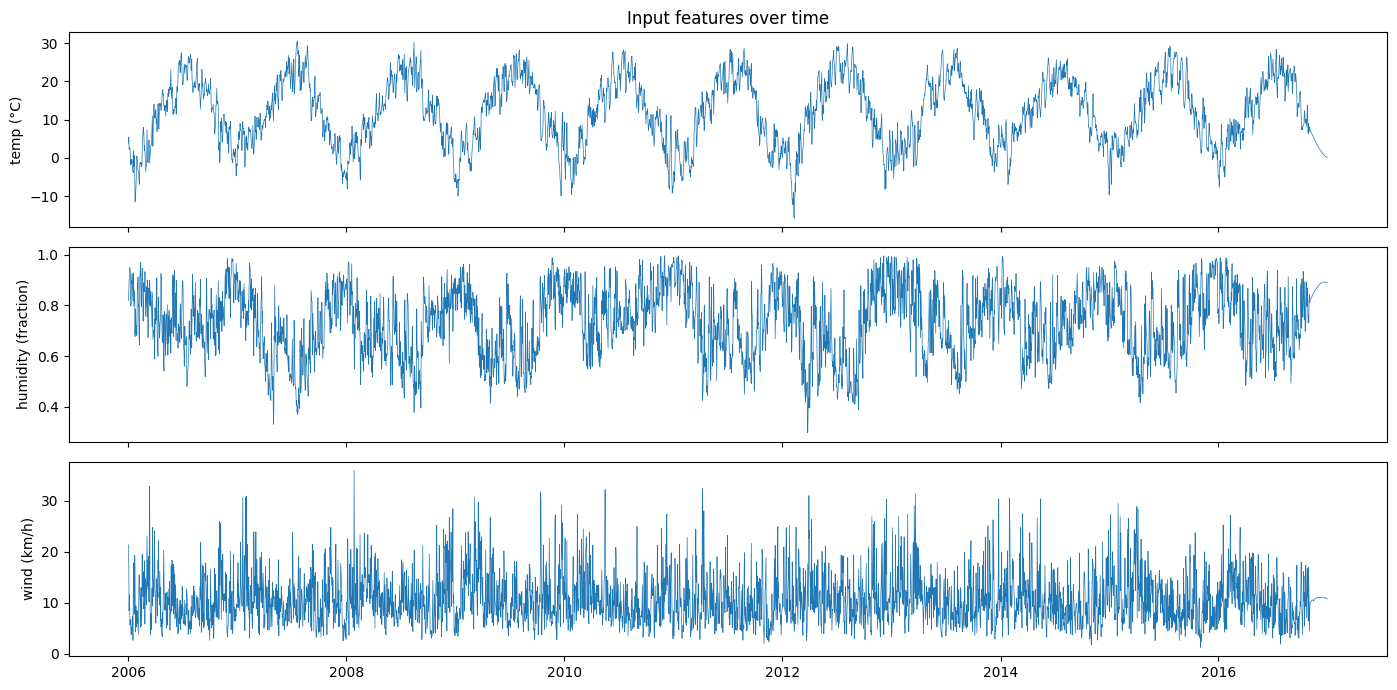

Correlation with temperature:
temp        1.000
humidity   -0.594
wind       -0.140
pressure   -0.323


In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily["temp"], lw=0.6, alpha=0.7, label="daily mean")
ax.plot(daily.index, daily["temp"].rolling(30, center=True).mean(), lw=2, label="30-day average")
ax.set_title("Daily mean temperature over time"); ax.set_ylabel("°C"); ax.legend()
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
for ax, col, unit in zip(axes, ["temp", "humidity", "wind"], ["°C", "fraction", "km/h"]):
    ax.plot(daily.index, daily[col], lw=0.5); ax.set_ylabel(f"{col} ({unit})")
axes[0].set_title("Input features over time")
plt.tight_layout(); plt.show()

print("Correlation with temperature:")
print(daily.corr()["temp"].round(3).to_string())

### A3. Scaling, sequences and chronological split
- **Chronological split** (70% train / 15% validation / 15% test). Time series are *never* shuffled before splitting, otherwise the model would see the future.
- **MinMaxScaler is fitted on the training period only**, to avoid leaking information from validation/test data.
- Each sample is a window of the past **14 days × 3 features**. The target is the **next day's temperature**.

In [6]:
FEATURES = ["temp", "humidity", "wind"]       # add "pressure" here to use it as an optional 4th feature
SEQ_LEN = 14
N_FEAT = len(FEATURES)

values = daily[FEATURES].values
n = len(values)
n_train, n_val = int(n * 0.70), int(n * 0.15)

scaler = MinMaxScaler().fit(values[:n_train])          # fit on training period only
scaled = scaler.transform(values)

X, y, target_idx = [], [], []
for t in range(SEQ_LEN, n):
    X.append(scaled[t - SEQ_LEN:t])                     # days t-14 ... t-1
    y.append(scaled[t, 0])                              # temperature on day t
    target_idx.append(t)
X, y, target_idx = np.array(X), np.array(y), np.array(target_idx)

train_m = target_idx < n_train
val_m   = (target_idx >= n_train) & (target_idx < n_train + n_val)
test_m  = target_idx >= n_train + n_val

X_train, y_train = X[train_m], y[train_m]
X_val,   y_val   = X[val_m],   y[val_m]
X_test,  y_test  = X[test_m],  y[test_m]
test_dates = daily.index[target_idx[test_m]]

print("X shape:", X.shape, "-> (samples, timesteps, features)")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("Train period:", daily.index[0].date(), "->", daily.index[n_train-1].date())
print("Val period  :", daily.index[n_train].date(), "->", daily.index[n_train+n_val-1].date())
print("Test period :", daily.index[n_train+n_val].date(), "->", daily.index[-1].date())

# helper: convert scaled temperature back to °C
def to_celsius(s):
    return (np.asarray(s) - scaler.min_[0]) / scaler.scale_[0]

X shape: (4004, 14, 3) -> (samples, timesteps, features)
Train: 2798 | Val: 602 | Test: 604
Train period: 2006-01-01 -> 2013-09-12
Val period  : 2013-09-13 -> 2015-05-07
Test period : 2015-05-08 -> 2016-12-31


## Part B: SimpleRNN Model Development
### B3–B4. Build and compile
Input (14 × 3) → SimpleRNN(64) → Dropout(0.2) → Dense(1, linear)  
Loss = MSE, optimizer = Adam, metric = MAE.

In [7]:
def build_model(units=64, dropout=0.2, lr=1e-3):
    model = keras.Sequential([
        keras.Input(shape=(SEQ_LEN, N_FEAT)),
        layers.SimpleRNN(units),
        layers.Dropout(dropout),
        layers.Dense(1, activation="linear"),
    ], name="simple_rnn_temp")
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse", metrics=["mae"])
    return model

model = build_model()
model.summary()

Model: "simple_rnn_temp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

### B5. Train (batch size 32, up to 100 epochs, early stopping on validation loss)

In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint("best_rnn.keras", monitor="val_loss", save_best_only=True),
]
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=100, batch_size=32, callbacks=callbacks, verbose=2)

Epoch 1/100
88/88 - 3s - 38ms/step - loss: 0.0416 - mae: 0.1516 - val_loss: 0.0055 - val_mae: 0.0593
Epoch 2/100
88/88 - 1s - 11ms/step - loss: 0.0131 - mae: 0.0904 - val_loss: 0.0035 - val_mae: 0.0469
Epoch 3/100
88/88 - 1s - 8ms/step - loss: 0.0109 - mae: 0.0834 - val_loss: 0.0030 - val_mae: 0.0435
Epoch 4/100
88/88 - 1s - 6ms/step - loss: 0.0086 - mae: 0.0736 - val_loss: 0.0040 - val_mae: 0.0515
Epoch 5/100
88/88 - 0s - 6ms/step - loss: 0.0079 - mae: 0.0704 - val_loss: 0.0031 - val_mae: 0.0446
Epoch 6/100
88/88 - 1s - 6ms/step - loss: 0.0070 - mae: 0.0668 - val_loss: 0.0031 - val_mae: 0.0443
Epoch 7/100
88/88 - 1s - 6ms/step - loss: 0.0064 - mae: 0.0638 - val_loss: 0.0028 - val_mae: 0.0423
Epoch 8/100
88/88 - 1s - 6ms/step - loss: 0.0064 - mae: 0.0627 - val_loss: 0.0021 - val_mae: 0.0361
Epoch 9/100
88/88 - 1s - 6ms/step - loss: 0.0055 - mae: 0.0591 - val_loss: 0.0023 - val_mae: 0.0384
Epoch 10/100
88/88 - 1s - 6ms/step - loss: 0.0056 - mae: 0.0592 - val_loss: 0.0024 - val_mae: 0.03

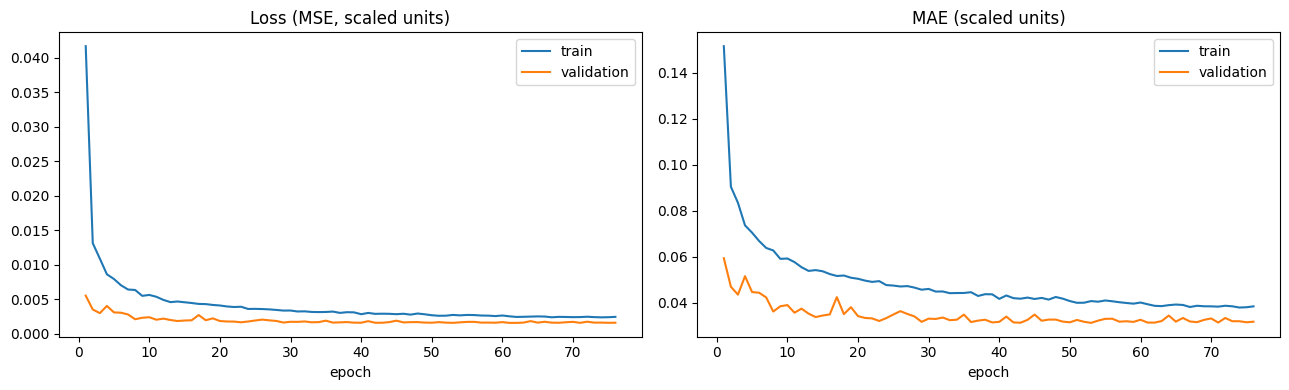

Stopped after 76 epochs | best epoch = 61 | best val loss = 0.00159


In [9]:
h = history.history
ep = range(1, len(h["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(ep, h["loss"], label="train"); ax[0].plot(ep, h["val_loss"], label="validation")
ax[0].set_title("Loss (MSE, scaled units)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(ep, h["mae"], label="train"); ax[1].plot(ep, h["val_mae"], label="validation")
ax[1].set_title("MAE (scaled units)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
best = int(np.argmin(h["val_loss"]))
print(f"Stopped after {len(ep)} epochs | best epoch = {best+1} | best val loss = {h['val_loss'][best]:.5f}")

## Part C: Evaluation and Forecasting
### C6. Test-set metrics (in °C)

In [10]:
pred_c = to_celsius(model.predict(X_test, verbose=0).ravel())
true_c = to_celsius(y_test)

# Naive baseline: "tomorrow = today". Any useful model should beat it.
naive_c = to_celsius(X_test[:, -1, 0])

def metrics(t, p):
    return {"RMSE (°C)": np.sqrt(mean_squared_error(t, p)),
            "MAE (°C)": mean_absolute_error(t, p),
            "R²": r2_score(t, p)}

results = pd.DataFrame({"SimpleRNN": metrics(true_c, pred_c),
                        "Persistence baseline": metrics(true_c, naive_c)}).T
display(results.round(3))

,RMSE (°C),MAE (°C),R²
SimpleRNN,1.878,1.415,0.951
Persistence baseline,2.035,1.485,0.942


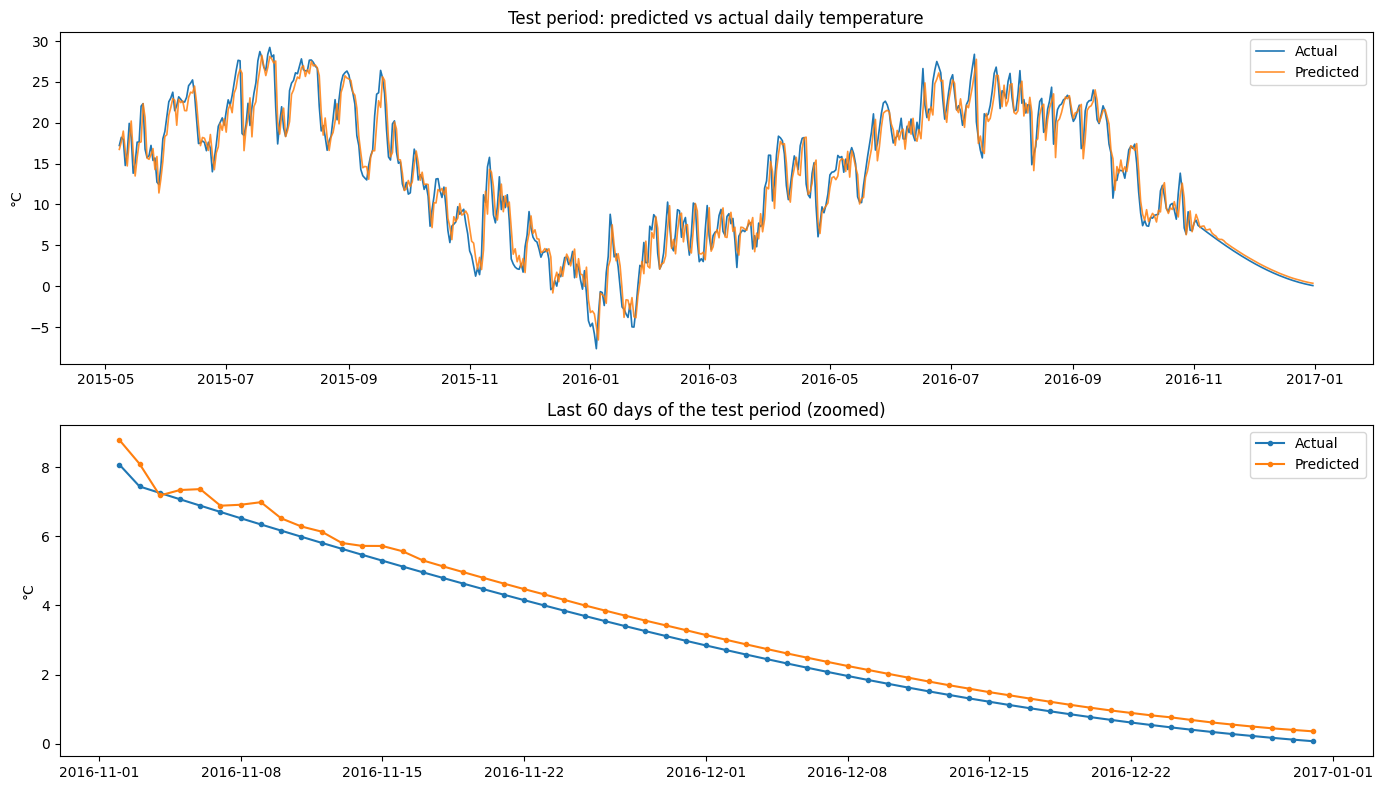

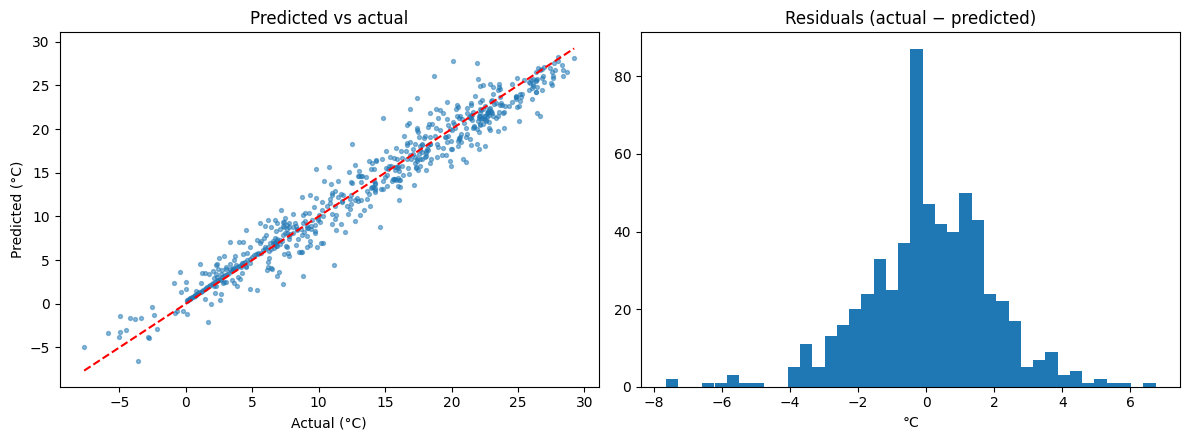

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(test_dates, true_c, label="Actual", lw=1.2)
axes[0].plot(test_dates, pred_c, label="Predicted", lw=1.2, alpha=0.85)
axes[0].set_title("Test period: predicted vs actual daily temperature"); axes[0].set_ylabel("°C"); axes[0].legend()

zoom = slice(-60, None)
axes[1].plot(test_dates[zoom], true_c[zoom], "o-", ms=3, label="Actual")
axes[1].plot(test_dates[zoom], pred_c[zoom], "o-", ms=3, label="Predicted")
axes[1].set_title("Last 60 days of the test period (zoomed)"); axes[1].set_ylabel("°C"); axes[1].legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(true_c, pred_c, s=8, alpha=0.5)
lims = [min(true_c.min(), pred_c.min()), max(true_c.max(), pred_c.max())]
ax[0].plot(lims, lims, "r--"); ax[0].set_xlabel("Actual (°C)"); ax[0].set_ylabel("Predicted (°C)")
ax[0].set_title("Predicted vs actual")
ax[1].hist(true_c - pred_c, bins=40); ax[1].set_title("Residuals (actual − predicted)"); ax[1].set_xlabel("°C")
plt.tight_layout(); plt.show()

### C7. Forecast the next 7 days
The model predicts **only temperature**, but its input also needs humidity and wind speed. For the future days those are unknown, so the forecast is **recursive** and assumes humidity and wind stay at their **average over the last 7 days**. Each predicted temperature is fed back in as the newest day. Errors compound, so confidence falls with each extra day.

,date,forecast temp (°C)
0,2017-01-01,0.31
1,2017-01-02,0.55
2,2017-01-03,0.73
3,2017-01-04,0.87
4,2017-01-05,0.98
5,2017-01-06,1.09
6,2017-01-07,1.19


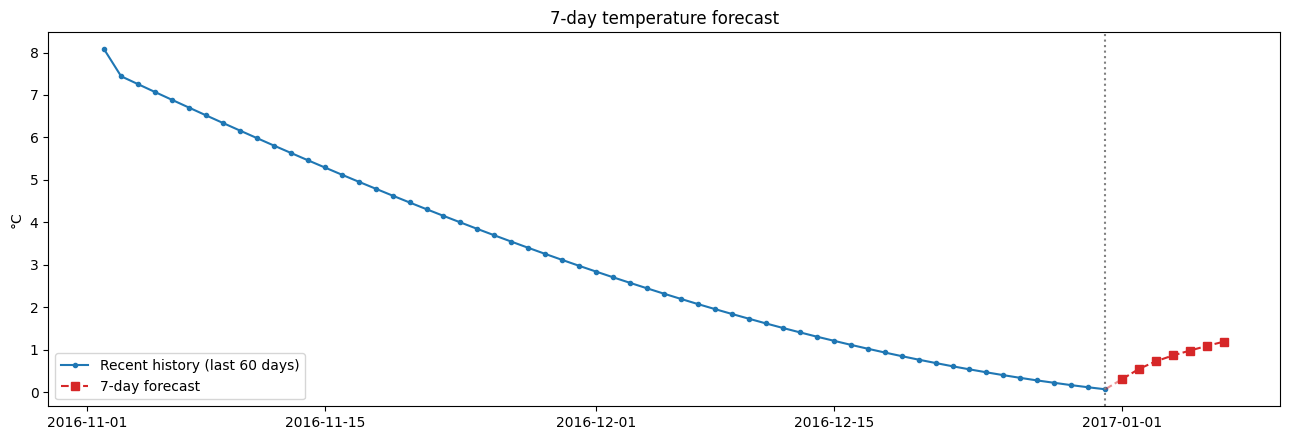

In [12]:
def forecast_next_days(model, last_window, days=7):
    window = last_window.copy()                      # (SEQ_LEN, N_FEAT), scaled
    other = window[-7:, 1:].mean(axis=0)             # assumed humidity / wind for future days
    preds = []
    for _ in range(days):
        p = model.predict(window[None, ...], verbose=0)[0, 0]
        preds.append(p)
        window = np.vstack([window[1:], np.concatenate([[p], other])])
    return to_celsius(preds)

forecast_c = forecast_next_days(model, scaled[-SEQ_LEN:], days=7)
future_dates = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=7, freq="D")

forecast_df = pd.DataFrame({"date": future_dates.date, "forecast temp (°C)": forecast_c.round(2)})
display(forecast_df)

HIST = 60
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index[-HIST:], daily["temp"].iloc[-HIST:], "o-", ms=3, label=f"Recent history (last {HIST} days)")
ax.plot(future_dates, forecast_c, "s--", color="tab:red", label="7-day forecast")
ax.plot([daily.index[-1], future_dates[0]], [daily["temp"].iloc[-1], forecast_c[0]], "--", color="tab:red", alpha=0.5)
ax.axvline(daily.index[-1], color="gray", ls=":")
ax.set_title("7-day temperature forecast"); ax.set_ylabel("°C"); ax.legend()
plt.tight_layout(); plt.show()